In [1]:
import numpy as np
import json 
import matplotlib.pyplot as plt
import os
import matplotlib as mpl
mpl.style.use('./PPC/paper.mcstyle')


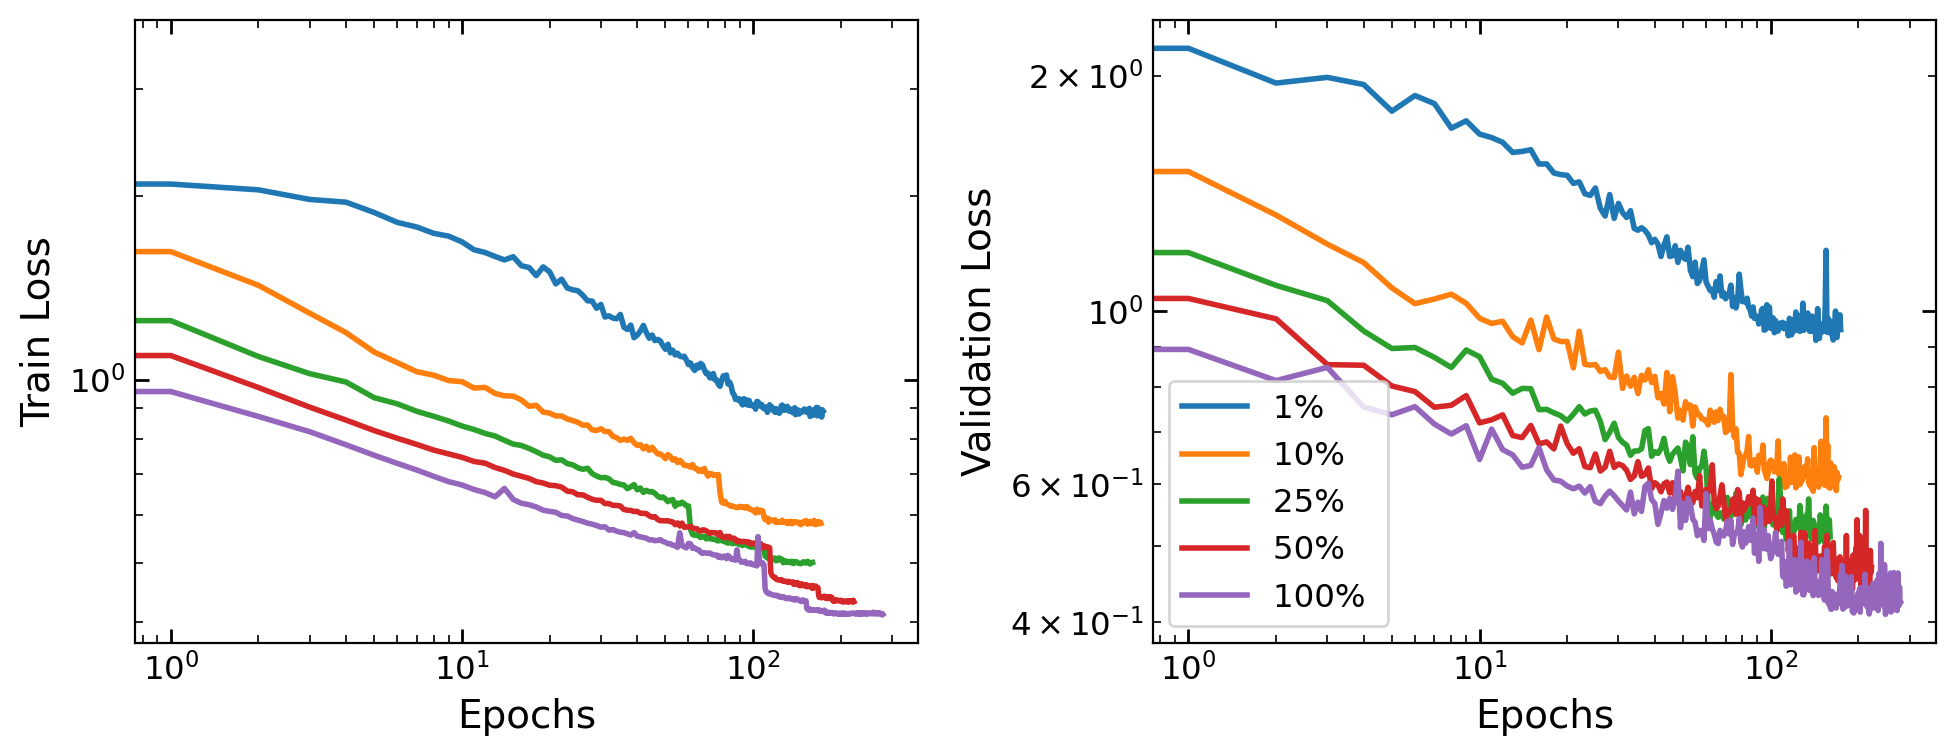

In [4]:
data_dir = "../logs/"
ablation_files_name = ['Odisseo_1percent',
                        'Odisseo_10percent',
                        'Odisseo_25percent',
                        'Odisseo_50percent',
                        # 'Odisseo_75percent',
                          'Odisseo_100percent'
                        ]
label_percent = [1, 
                 10,
                  25,
                  50,
                #   75,
                  100
                 ]
name = 'latest/loss_history.json'
keys = ['train_loss_history', 'val_loss_history']

fig = plt.figure(figsize=(10, 4), tight_layout=True)
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)
for perc, file_name in zip(label_percent, ablation_files_name):
    path = os.path.join(data_dir, file_name, name)
    with open(path, 'r') as f:
        loss_history = json.load(f)
    train_loss = np.array(loss_history[keys[0]])
    epoch_train = len(train_loss)
    val_loss = np.array(loss_history[keys[1]])
    epoch_val = len(val_loss)
    ax1.plot(np.arange(epoch_train), train_loss, label=f'{perc}% ')
    ax1.set_ylabel('Train Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    # ax1.legend()
    ax2.plot(np.arange(epoch_val), val_loss, label=f'{perc}% ')
    ax2.set_ylabel('Validation Loss')
    ax2.set_xlabel('Epochs')
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.legend()